In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

In [ ]:
def find_target_col(df):
    for c in df.columns:
        if c == "Churn":
            return c
    for c in df.columns:
        if "churn" in c.lower():
            return c
    raise ValueError("No churn-like target column found.")

def to_binary(series: pd.Series) -> pd.Series:
    if series.dtype.name == "category":
        series = series.astype(str)
    if series.dtype == bool:
        return series.astype(int)
    s = series.astype(str).str.strip().str.lower()
    true_vals = {"yes", "true", "1", "churned", "y", "t"}
    return s.isin(true_vals).astype(int)

In [50]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SGDClassifier(
        loss="log_loss",
        max_iter=5000,
        alpha=1e-4,
        early_stopping=True,
        n_iter_no_change=5,
        penalty="l2",
        class_weight="balanced",
        random_state=42
    ))
])

In [51]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)

val_probs = pipeline.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)


=== Validation Results ===
AUC:       0.5743
Accuracy:  0.5405
Confusion matrix:
 [[3761 3507]
 [1184 1758]]

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.52      0.62      7268
           1       0.33      0.60      0.43      2942

    accuracy                           0.54     10210
   macro avg       0.55      0.56      0.52     10210
weighted avg       0.64      0.54      0.56     10210



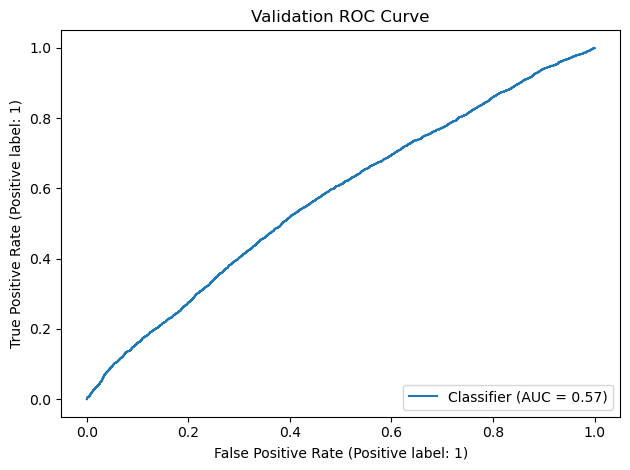

In [ ]:
print("\n=== Validation Results ===")
print(f"AUC:       {roc_auc_score(y_val, val_probs):.4f}")
print(f"Accuracy:  {accuracy_score(y_val, val_preds):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_val, val_preds))
print("\nClassification report:\n", classification_report(y_val, val_preds))

RocCurveDisplay.from_predictions(y_val, val_probs)
plt.title("Validation ROC Curve")
plt.tight_layout()
plt.show()

holdout_probs = pipeline.predict_proba(X_holdout)[:, 1]
holdout_preds = (holdout_probs >= 0.5).astype(int)

cust_id_col = [c for c in holdout_data.columns if "customerid" in c.lower()][0]
out = holdout_data[[cust_id_col]].copy()
out["prob"] = holdout_probs
out["pred"] = holdout_preds
out.to_csv("holdout_predictions_linearsgd.csv", index=False)